# WFP Global Food Prices 2026
# Exploratory Data Analysis & DBSCAN Clustering


## 1. Setup

In [43]:
# Import all libraries 

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

## 2. Load & Inspect Data

In [44]:
df = pd.read_csv('wfp_food_prices_global_2026.csv')
print('Shape:', df.shape)

Shape: (85289, 17)


In [45]:
df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Bread,55,KG,aggregate,Retail,AFN,77.00,1.16
1,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (high quality),247,KG,aggregate,Retail,AFN,127.93,1.93
2,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (low quality),145,KG,aggregate,Retail,AFN,48.70,0.73
3,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat,84,KG,aggregate,Retail,AFN,26.74,0.40
4,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat flour (high quality),178,KG,aggregate,Retail,AFN,31.26,0.47


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85289 entries, 0 to 85288
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   countryiso3   85289 non-null  object 
 1   date          85289 non-null  object 
 2   admin1        85260 non-null  object 
 3   admin2        85260 non-null  object 
 4   market        85289 non-null  object 
 5   market_id     85289 non-null  int64  
 6   latitude      85260 non-null  float64
 7   longitude     85260 non-null  float64
 8   category      85289 non-null  object 
 9   commodity     85289 non-null  object 
 10  commodity_id  85289 non-null  int64  
 11  unit          85289 non-null  object 
 12  priceflag     85289 non-null  object 
 13  pricetype     85289 non-null  object 
 14  currency      85289 non-null  object 
 15  price         85289 non-null  float64
 16  usdprice      84949 non-null  float64
dtypes: float64(4), int64(2), object(11)
memory usage: 11.1+ MB


In [47]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
countryiso3,85289,60,SYR,14380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,85289,6,2026-01-15,28418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admin1,85260,559,Southern Region,2410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admin2,85260,1279,Rural Damascus,874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,85289,1730,Qaryatein,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market_id,85289.0,NaN,NaN,NaN,2896.821173,2179.025312,80.0,1548.0,2354.0,3912.0,11721.0
latitude,85260.0,NaN,NaN,NaN,17.154274,16.023934,-30.4,7.22,13.56,32.89,51.5
longitude,85260.0,NaN,NaN,NaN,42.368389,39.051818,-90.52,17.96,36.04,49.13,140.7
category,85289,8,cereals and tubers,23425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commodity,85289,541,Sugar,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Column reference**
1. countryiso3: ISO3 country code 
2. date: Reporting date (monthly)
3. admin1 / admin2: Sub-national administrative regions
4. market / market_id: Market name / unique numeric id
5. latitude / longitude: Market coordinates
6. category: Food category (8 categories)
7. commodity / commodity_id: Specific commodity (541 unique commodities)
8. unit: Unit of measure (KG, L, etc.)
9. priceflag: Whether the price is `actual` or `aggregate`
10. pricetype: `Retail` or `Wholesale`
11. currency: Local currency code
12. price: Price in local currency
13. usdprice: Price converted to USD (our main analysis variable)

## 3. Data Quality: Missing Values


In [48]:
# Finding Missing values

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print('\n% of rows affected:')
print((missing/len(df)*100).round(3))

usdprice     340
admin1        29
admin2        29
latitude      29
longitude     29
dtype: int64

% of rows affected:
usdprice     0.399
admin1       0.034
admin2       0.034
latitude     0.034
longitude    0.034
dtype: float64


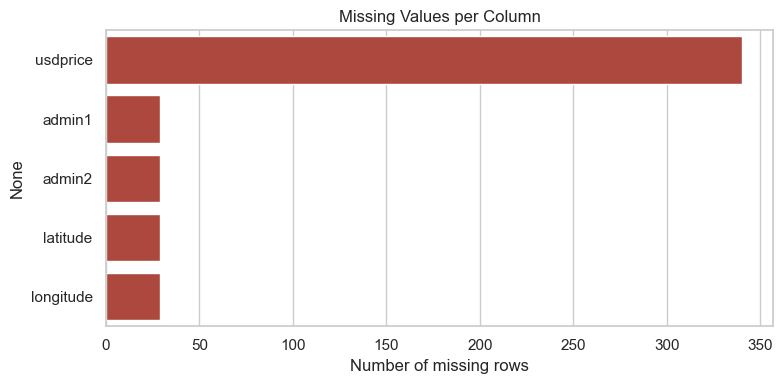

In [49]:
# Missing values per column

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color='#c0392b')
ax.set_title('Missing Values per Column')
ax.set_xlabel('Number of missing rows')
plt.tight_layout()
plt.show()

**Observation:** missingness is tiny (≤340 rows, <0.4% of the data) and concentrated in `latitude`/`longitude`/`admin1`/`admin2` (same 29 rows — likely markets missing geocoding) and `usdprice` (340 rows — likely missing exchange rate for that month/currency). Given the negligible volume, we simply drop these rows rather than impute, to avoid injecting bias into price or geography figures.


## 4. Data Cleaning

In [50]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

df_clean = df.dropna(subset=['latitude', 'longitude', 'usdprice']).copy()
print('Rows before cleaning:', len(df), '| after cleaning:', len(df_clean))

Rows before cleaning: 85289 | after cleaning: 84920


In [51]:
Q1 = df_clean['usdprice'].quantile(0.25)
Q3 = df_clean['usdprice'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5*IQR
pct_outliers = (df_clean['usdprice'] > upper_fence).mean()*100
print(f'IQR upper fence: {upper_fence:.2f} USD')
print(f'% of records above upper fence (statistical outliers): {pct_outliers:.2f}%')

IQR upper fence: 22.94 USD
% of records above upper fence (statistical outliers): 21.63%


~21.6% of records sit above the classic IQR fence. This is expected for price data (highly right-skewed — a few luxury/rare commodities and hyperinflation currencies pull the tail far right) — not a data-entry error. We keep these rows but will use a **log transform** for visualization and clustering to tame the skew.

<a id="5"></a>
## 5. Univariate & Categorical EDA

Exploring the composition of the dataset: which categories, countries, and commodities dominate the reporting.

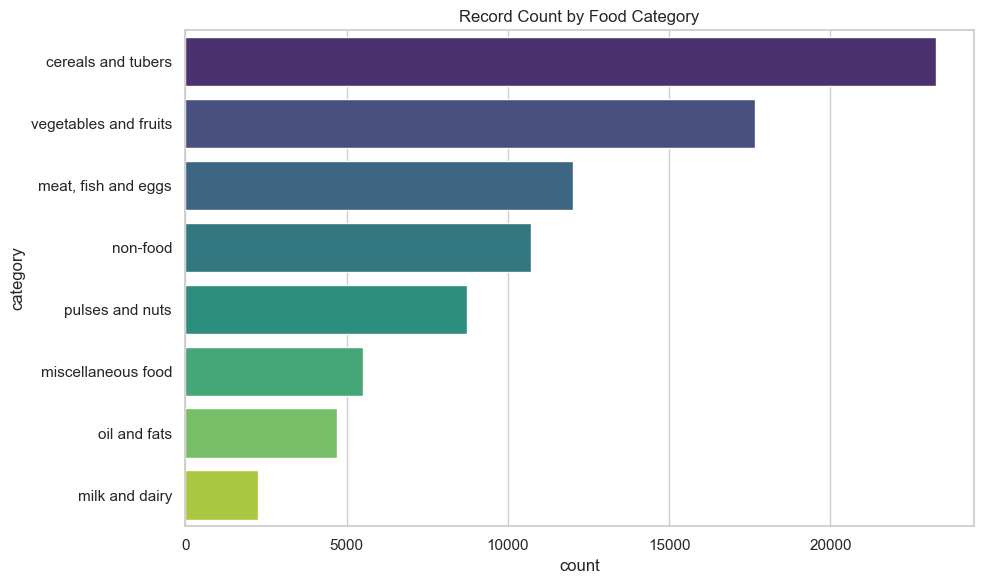

In [52]:
# Record count by food category

fig, ax = plt.subplots()
order = df_clean['category'].value_counts().index
sns.countplot(data=df_clean, y='category', order=order, palette='viridis', ax=ax)
ax.set_title('Record Count by Food Category')
plt.tight_layout()
plt.show()

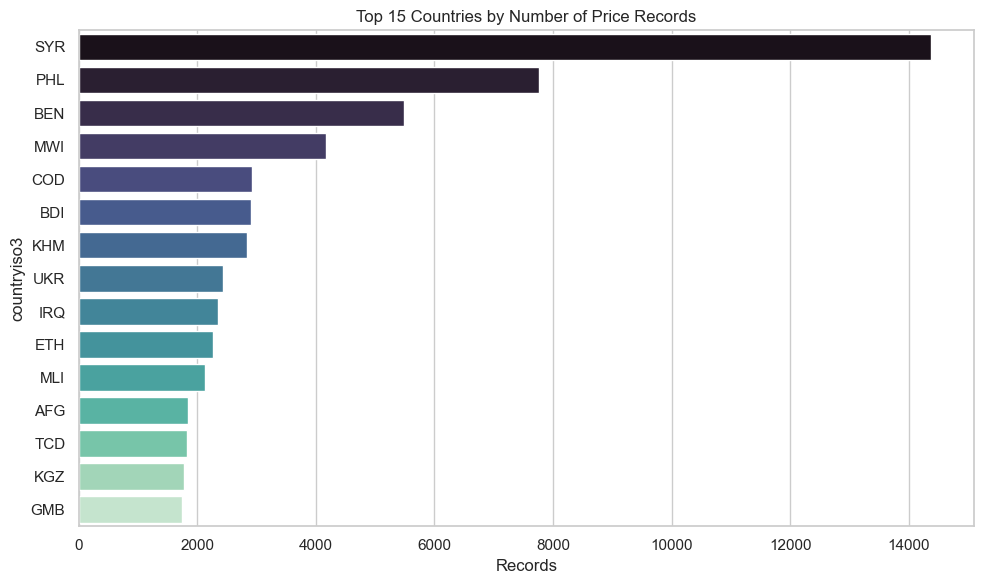

In [53]:
# Top 15 countries by number of records

fig, ax = plt.subplots()
top_c = df_clean['countryiso3'].value_counts().head(15)
sns.barplot(x=top_c.values, y=top_c.index, palette='mako', ax=ax)
ax.set_title('Top 15 Countries by Number of Price Records')
ax.set_xlabel('Records')
plt.tight_layout()
plt.show()

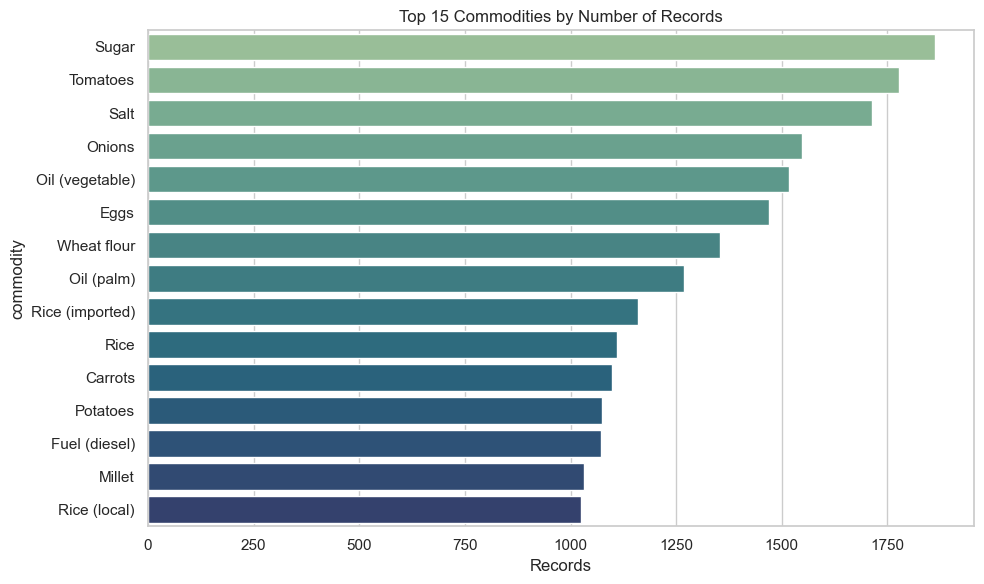

In [54]:
# Top 15 commodities by number of records

fig, ax = plt.subplots()
top_com = df_clean['commodity'].value_counts().head(15)
sns.barplot(x=top_com.values, y=top_com.index, palette='crest', ax=ax)
ax.set_title('Top 15 Commodities by Number of Records')
ax.set_xlabel('Records')
plt.tight_layout()
plt.show()

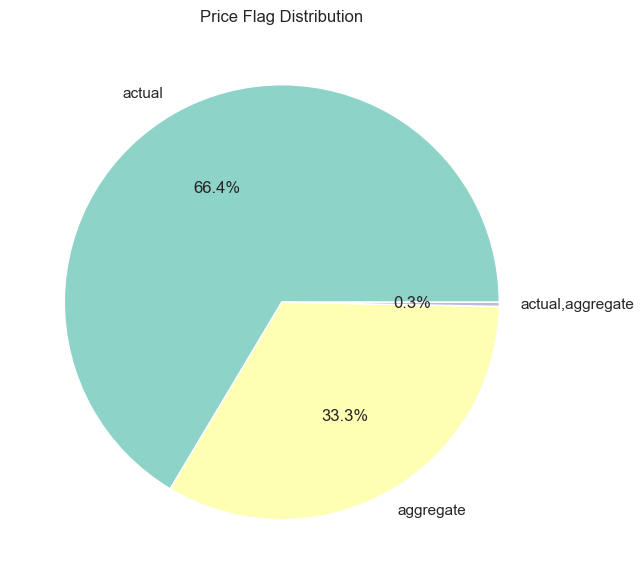

In [55]:
# Price flag distribution (aggregate vs actual)

fig, ax = plt.subplots()
df_clean['priceflag'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax, colors=sns.color_palette('Set3'))
ax.set_title('Price Flag Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

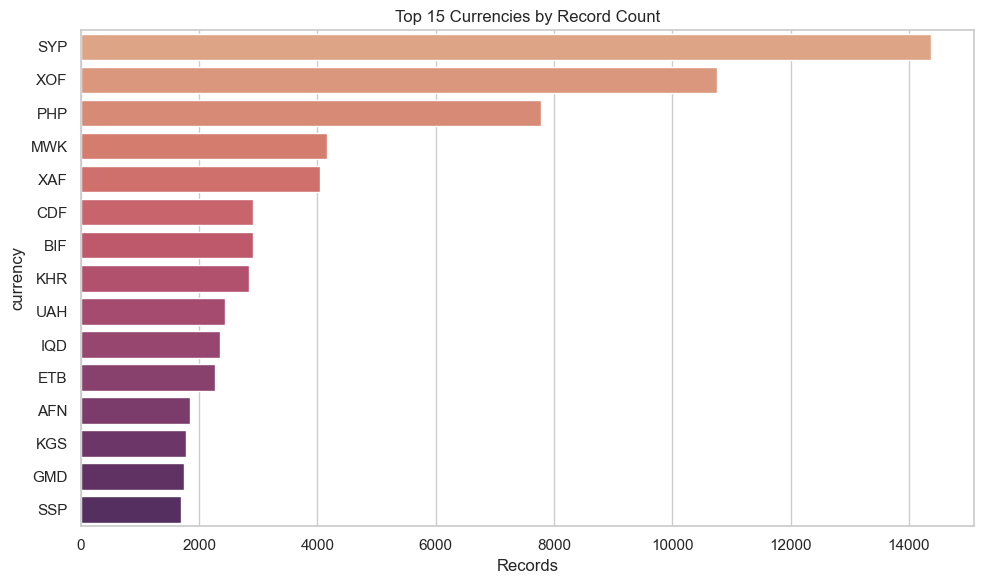

In [56]:
# Top 15 currencies by record count

fig, ax = plt.subplots()
top_cur = df_clean['currency'].value_counts().head(15)
sns.barplot(x=top_cur.values, y=top_cur.index, palette='flare', ax=ax)
ax.set_title('Top 15 Currencies by Record Count')
ax.set_xlabel('Records')
plt.tight_layout()
plt.show()

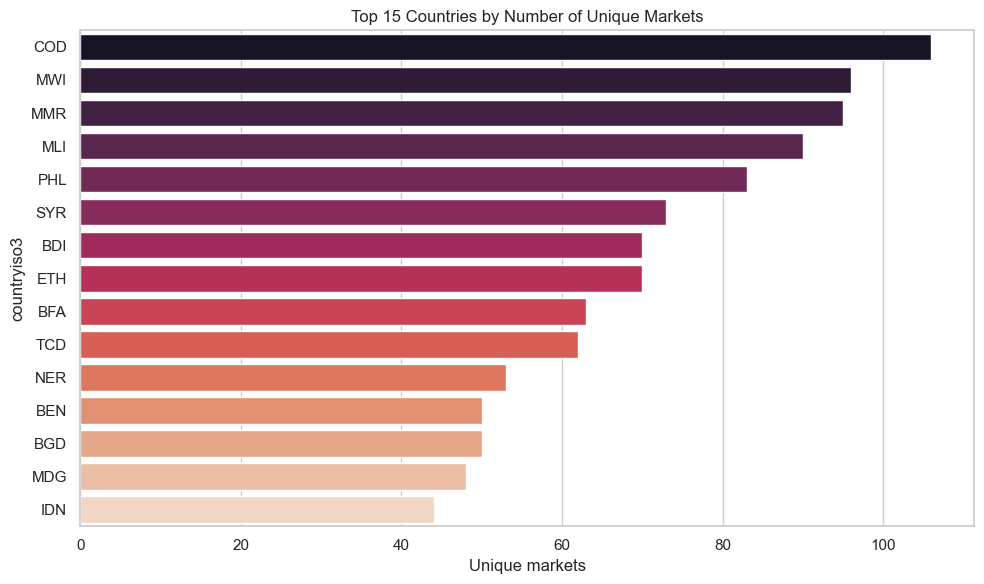

In [57]:
# Top 15 countries by number of unique markets monitored

fig, ax = plt.subplots()
mk = df_clean.groupby('countryiso3')['market_id'].nunique().sort_values(ascending=False).head(15)
sns.barplot(x=mk.values, y=mk.index, palette='rocket', ax=ax)
ax.set_title('Top 15 Countries by Number of Unique Markets')
ax.set_xlabel('Unique markets')
plt.tight_layout()
plt.show()

**Key findings so far:**
- `cereals and tubers` and `vegetables and fruits` are the most heavily reported categories.
- Reporting volume is highly uneven across countries — a handful of crisis-monitored countries (e.g. Syria, Philippines, Benin) dominate record counts.
- The vast majority of prices are `Retail` and flagged `aggregate` (averaged across sources), which is the standard WFP methodology.

<a id="6"></a>
## 6. Price Distribution Analysis


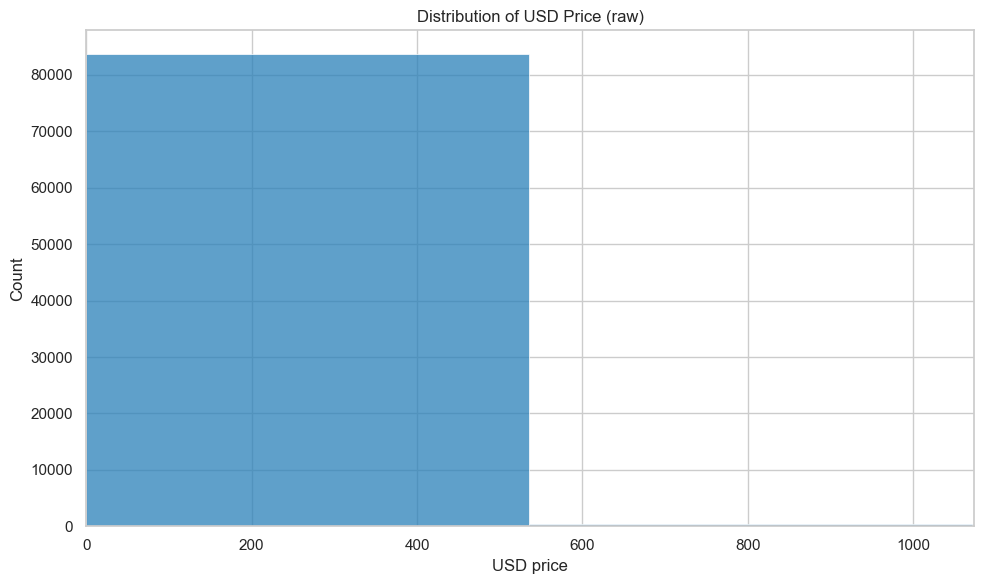

In [58]:
# Raw USD price distribution (clipped at 99th percentile for readability)

fig, ax = plt.subplots()
sns.histplot(df_clean['usdprice'], bins=100, color='#2980b9', ax=ax)
ax.set_title('Distribution of USD Price (raw)')
ax.set_xlim(0, df_clean['usdprice'].quantile(0.99))
ax.set_xlabel('USD price')
plt.tight_layout()
plt.show()

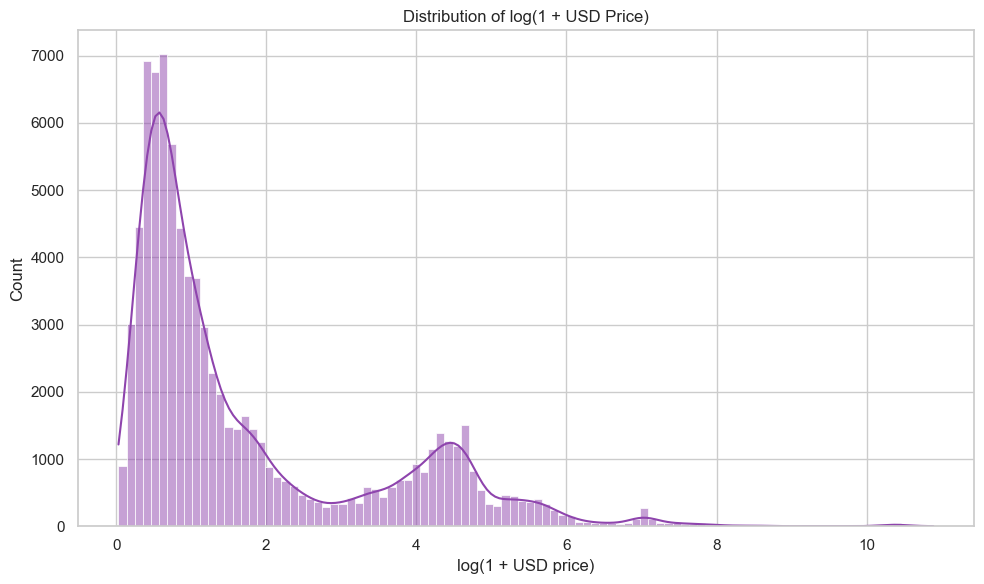

In [59]:
# log(1+usdprice) distribution - much closer to symmetric

fig, ax = plt.subplots()
sns.histplot(np.log1p(df_clean['usdprice']), bins=100, color='#8e44ad', kde=True, ax=ax)
ax.set_title('Distribution of log(1 + USD Price)')
ax.set_xlabel('log(1 + USD price)')
plt.tight_layout()
plt.show()

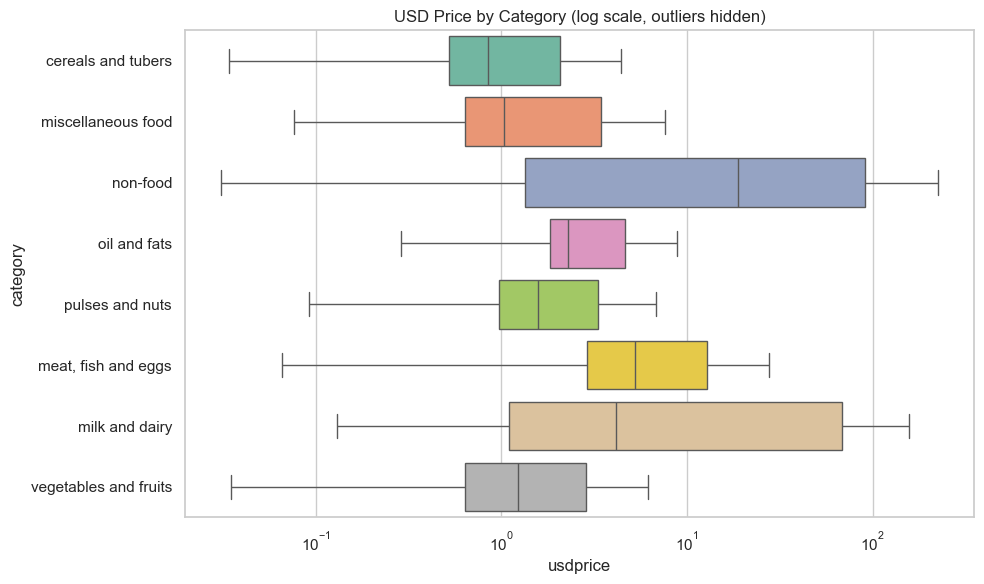

In [60]:
# USD price by category (log x-axis, outliers hidden for readability)

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df_clean, x='usdprice', y='category', palette='Set2', ax=ax, showfliers=False)
ax.set_xscale('log')
ax.set_title('USD Price by Category (log scale, outliers hidden)')
plt.tight_layout()
plt.show()

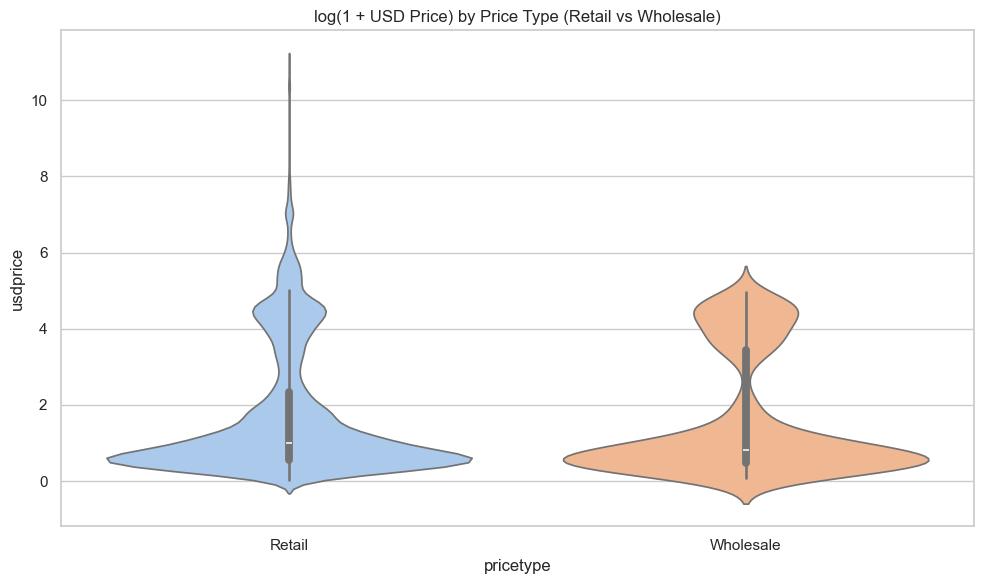

In [61]:
# Retail vs Wholesale price distributions

fig, ax = plt.subplots()
sns.violinplot(data=df_clean, x='pricetype', y=np.log1p(df_clean['usdprice']), palette='pastel', ax=ax)
ax.set_title('log(1 + USD Price) by Price Type (Retail vs Wholesale)')
plt.tight_layout()
plt.show()

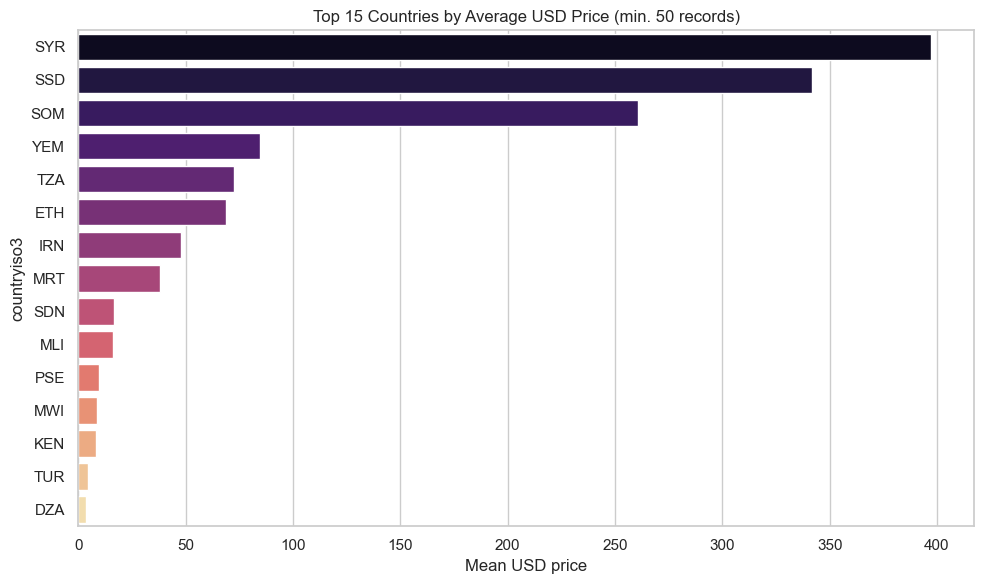

In [62]:
# Top 15 most expensive countries on average (min 50 records for reliability)

grp = df_clean.groupby('countryiso3')['usdprice'].agg(['mean','count'])
grp = grp[grp['count']>=50].sort_values('mean', ascending=False).head(15)
fig, ax = plt.subplots()
sns.barplot(x=grp['mean'].values, y=grp.index, palette='magma', ax=ax)
ax.set_title('Top 15 Countries by Average USD Price (min. 50 records)')
ax.set_xlabel('Mean USD price')
plt.tight_layout()
plt.show()

**Key findings:** `usdprice` is extremely right-skewed (raw histogram is dominated by a few very high values / hyperinflation currencies), but the log transform reveals an approximately unimodal, near-symmetric distribution — this justifies using `log1p(usdprice)` as the price feature for clustering later. Price levels differ noticeably by category (e.g. `meat, fish and eggs` typically prices higher per kg than `cereals and tubers`) and `Wholesale` prices trend slightly lower/wider than `Retail`, as expected.

<a id="7"></a>
## 7. Temporal Trends

Even though the dataset only spans a single year (2026, monthly snapshots), we can look at how average prices moved month to month, overall and by category.

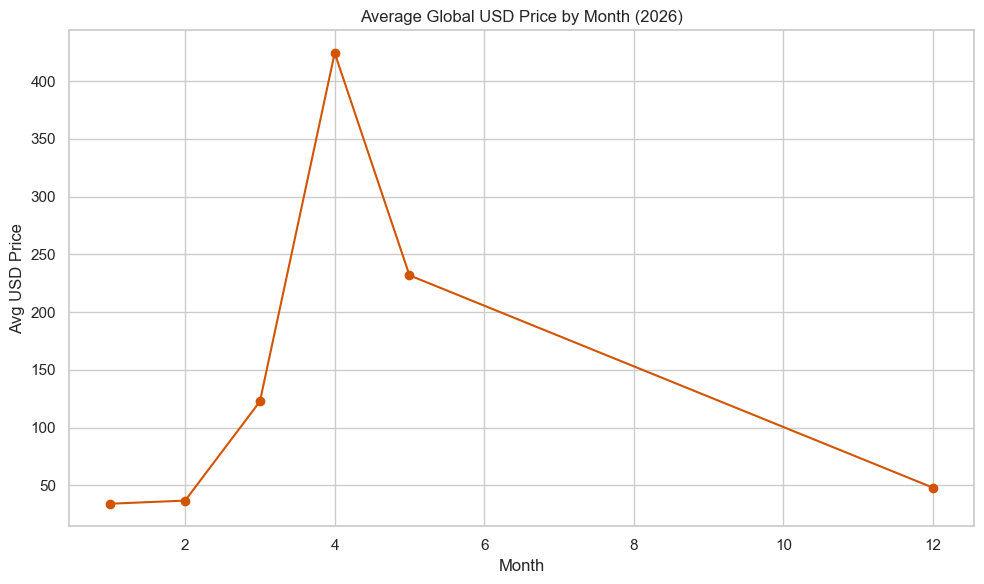

In [63]:
# Global average USD price trend by month

monthly = df_clean.groupby('month')['usdprice'].mean()
fig, ax = plt.subplots()
monthly.plot(marker='o', ax=ax, color='#d35400')
ax.set_title('Average Global USD Price by Month (2026)')
ax.set_xlabel('Month'); ax.set_ylabel('Avg USD Price')
plt.tight_layout()
plt.show()

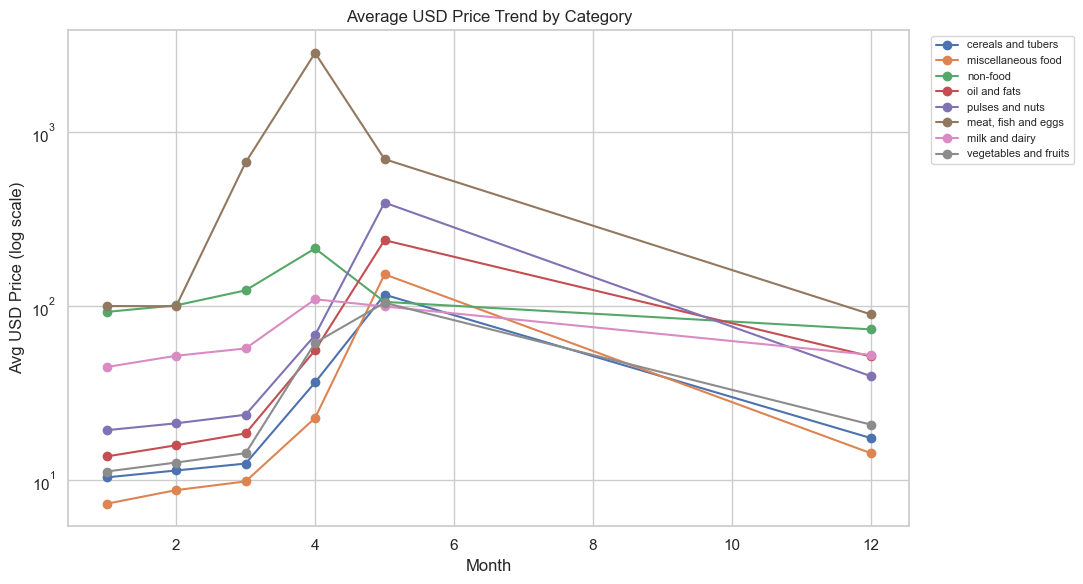

In [64]:
# Average USD price trend by category, per month

fig, ax = plt.subplots(figsize=(11,6))
for cat in df_clean['category'].unique():
    sub = df_clean[df_clean['category']==cat].groupby('month')['usdprice'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=cat)
ax.set_title('Average USD Price Trend by Category')
ax.set_xlabel('Month'); ax.set_ylabel('Avg USD Price (log scale)')
ax.set_yscale('log')
ax.legend(fontsize=8, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Key findings:** the global average is quite stable across the year at the aggregate level (fluctuations are muted once many countries/currencies are averaged together), but individual categories show more movement, and their price *levels* are naturally offset from one another on the log scale.

## 8. Geographic EDA

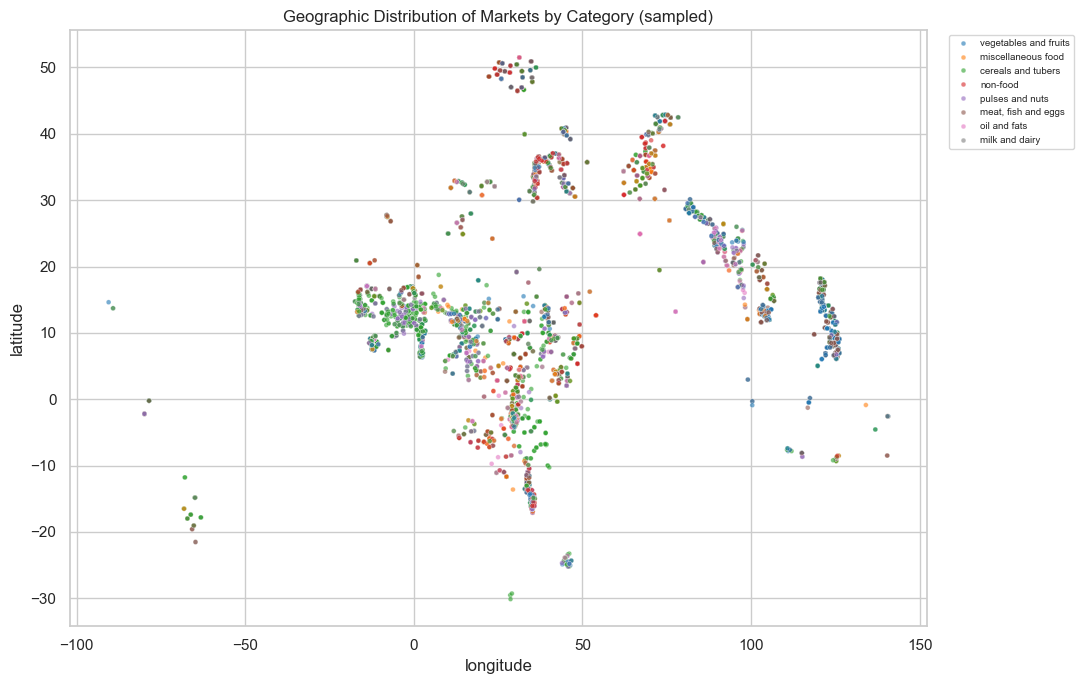

In [65]:
# Geographic distribution of markets, colored by category (sampled for plotting speed)

fig, ax = plt.subplots(figsize=(11,7))
sample = df_clean.sample(min(8000, len(df_clean)), random_state=42)
sns.scatterplot(data=sample, x='longitude', y='latitude', hue='category', s=12, alpha=0.6, ax=ax, palette='tab10')
ax.set_title('Geographic Distribution of Markets by Category (sampled)')
ax.legend(fontsize=7, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

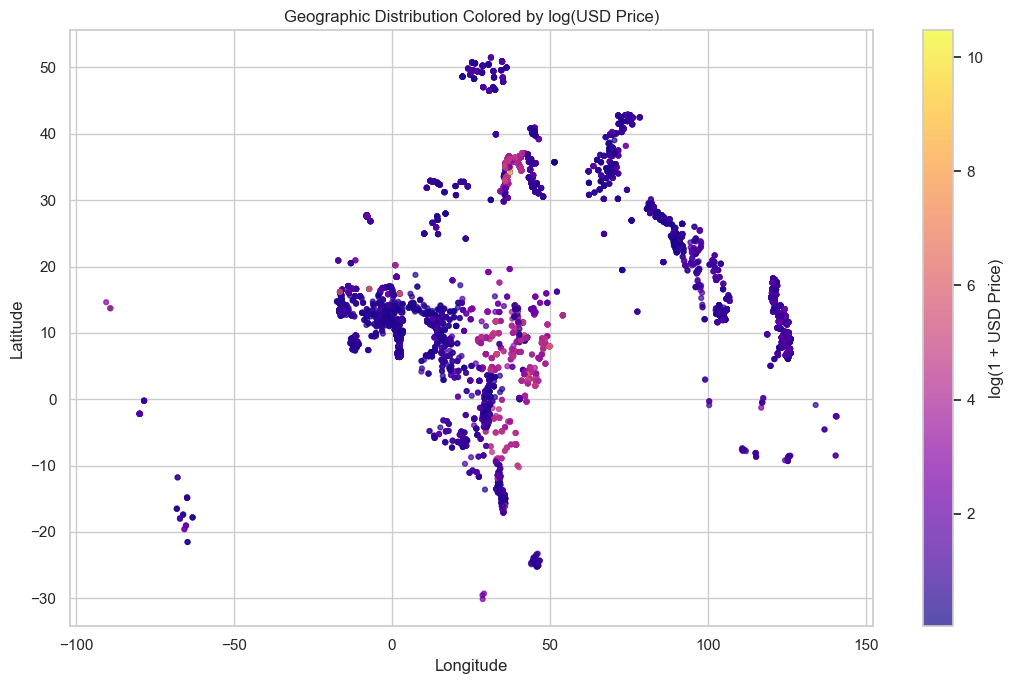

In [66]:
# Geographic distribution colored by log USD price

fig, ax = plt.subplots(figsize=(11,7))
sc = ax.scatter(sample['longitude'], sample['latitude'], c=np.log1p(sample['usdprice']), cmap='plasma', s=12, alpha=0.7)
plt.colorbar(sc, label='log(1 + USD Price)')
ax.set_title('Geographic Distribution Colored by log(USD Price)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

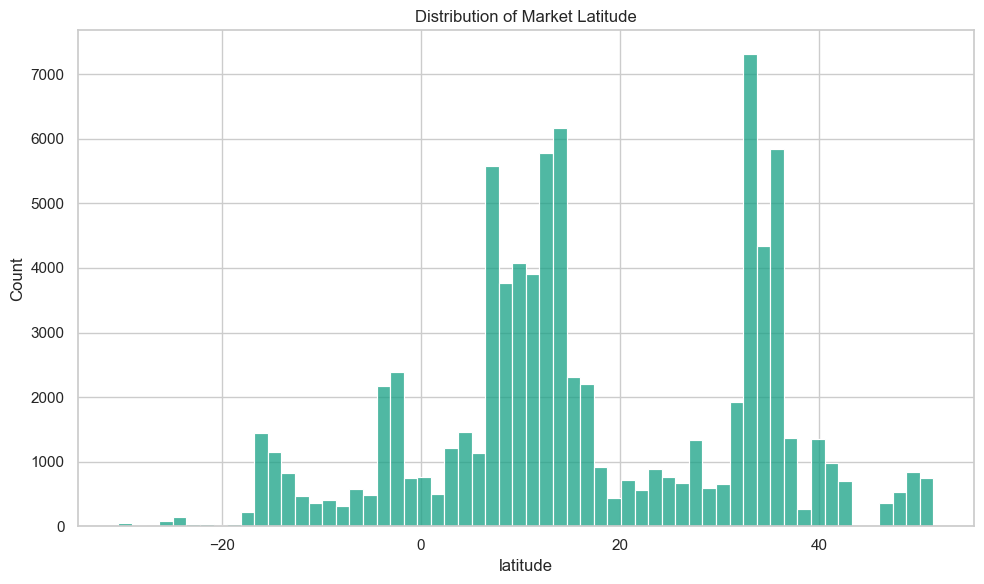

In [67]:
# Latitude distribution

fig, ax = plt.subplots()
sns.histplot(df_clean['latitude'], bins=60, color='#16a085', ax=ax)
ax.set_title('Distribution of Market Latitude')
plt.tight_layout()
plt.show()

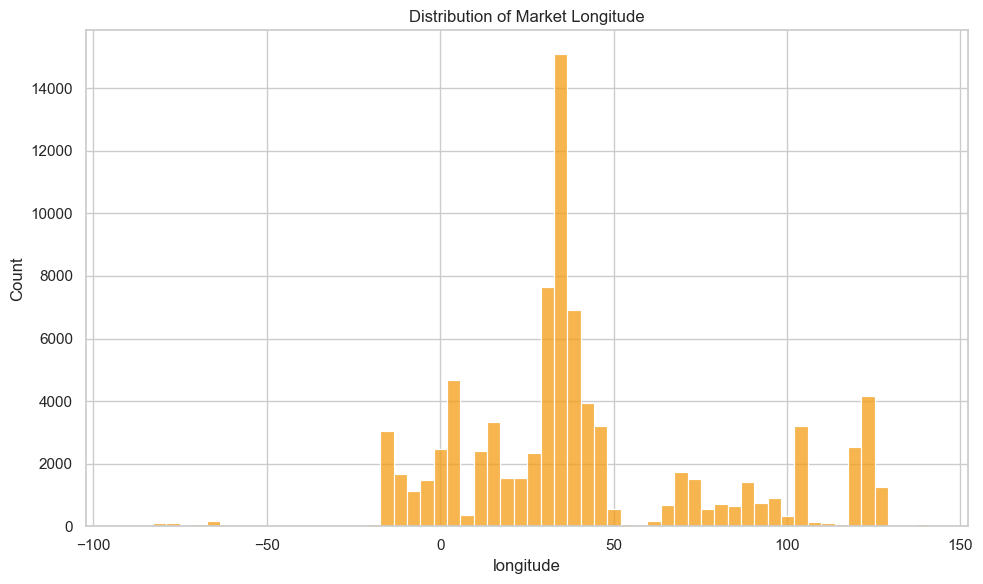

In [68]:
# Longitude distribution

fig, ax = plt.subplots()
sns.histplot(df_clean['longitude'], bins=60, color='#f39c12', ax=ax)
ax.set_title('Distribution of Market Longitude')
plt.tight_layout()
plt.show()

**Key findings:** monitored markets cluster heavily in the tropics/Northern hemisphere (Sub-Saharan Africa, South/Southeast Asia, Middle East), reflecting WFP's operational focus on food-insecure regions. Price levels visibly co-vary with geography — clusters of high-price markets are visible in specific regions, which is exactly the kind of structure DBSCAN is well-suited to discover.

<a id="9"></a>
## 9. Multivariate / Correlation EDA

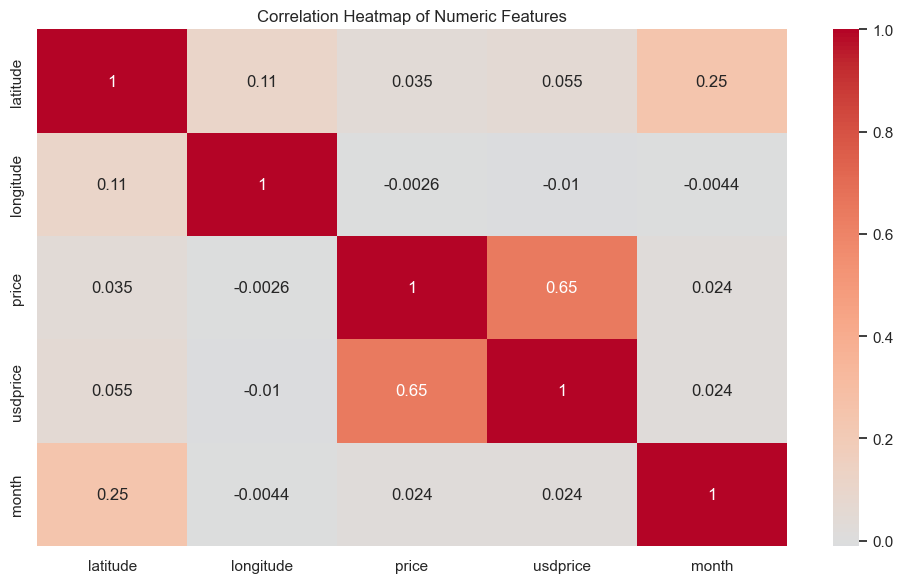

In [69]:
# Correlation heatmap of numeric features

num_cols = ['latitude','longitude','price','usdprice','month']
corr = df_clean[num_cols].corr()
fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

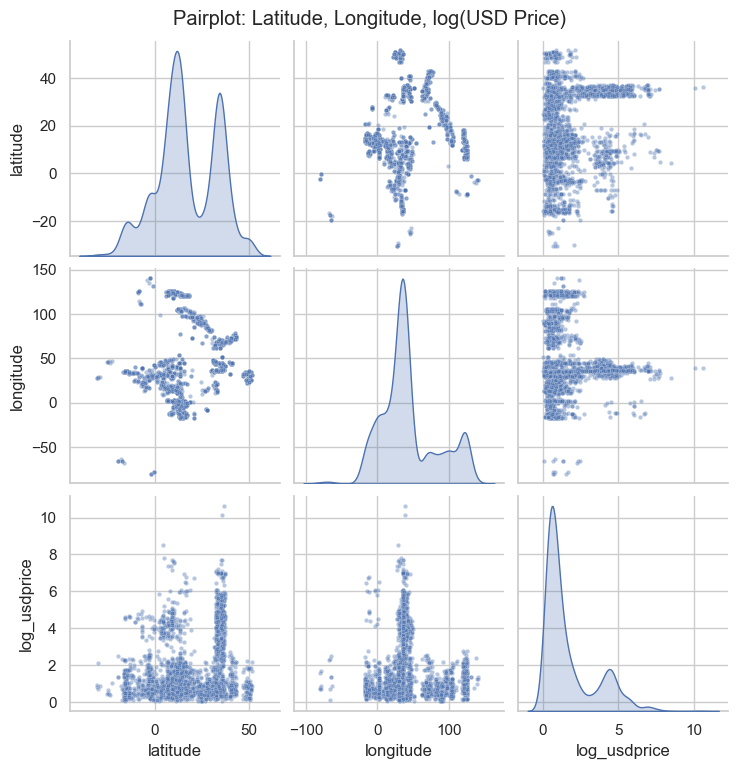

In [70]:
# Pairplot of latitude, longitude, and log price 

pp_df = df_clean[['latitude','longitude','usdprice']].copy()
pp_df['log_usdprice'] = np.log1p(pp_df['usdprice'])
pp = sns.pairplot(pp_df.sample(min(3000,len(pp_df)), random_state=1)[['latitude','longitude','log_usdprice']],
                   diag_kind='kde', plot_kws={'alpha':0.4,'s':10})
pp.fig.suptitle('Pairplot: Latitude, Longitude, log(USD Price)', y=1.02)
plt.show()

**Key findings:** `price` and `usdprice` are (unsurprisingly) the only strongly correlated pair among raw numeric columns — coordinates and month show essentially no linear correlation with price, confirming that price variation is driven by *local, non-linear* geographic/economic structure rather than a simple linear geographic gradient. This is exactly the kind of non-linear, density-based structure DBSCAN can capture where a method like k-means (which assumes convex, similarly-sized clusters) would struggle.

<a id="10"></a>
## 10. Feature Engineering for Clustering

In [71]:
cluster_df = (df_clean.assign(log_usdprice=np.log1p(df_clean['usdprice']))
              .groupby('market_id')
              .agg(latitude=('latitude','first'),
                   longitude=('longitude','first'),
                   countryiso3=('countryiso3','first'),
                   market=('market','first'),
                   log_usdprice=('log_usdprice','mean'),
                   n_records=('usdprice','size'))
              .reset_index())
print('Markets available for clustering:', cluster_df.shape)
cluster_df.head()

Markets available for clustering: (1722, 7)


,market_id,latitude,longitude,countryiso3,market,log_usdprice,n_records
0,80,-3.37,36.68,TZA,Arusha (urban),3.990229,22
1,81,-4.22,35.75,TZA,Babati,3.953346,21
2,82,-1.33,31.81,TZA,Bukoba,4.155319,18
3,84,-7.29,36.34,TZA,Dodoma (Majengo),4.211173,15
4,85,-7.77,35.70,TZA,Iringa Urban,4.188728,21


In [72]:
features = ['latitude', 'longitude', 'log_usdprice']
X = cluster_df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled feature matrix shape:', X_scaled.shape)
pd.DataFrame(X_scaled, columns=features).describe().loc[['mean','std','min','max']]

Scaled feature matrix shape: (1722, 3)


,latitude,longitude,log_usdprice
mean,-4.126264e-17,9.903035e-17,-1.712400e-16
std,1.000290e+00,1.000290e+00,1.000290e+00
min,-2.627562e+00,-3.274552e+00,-1.013966e+00
max,2.628261e+00,2.547870e+00,3.122804e+00


<a id="11"></a>
## 11. Choosing DBSCAN — The k-distance graph


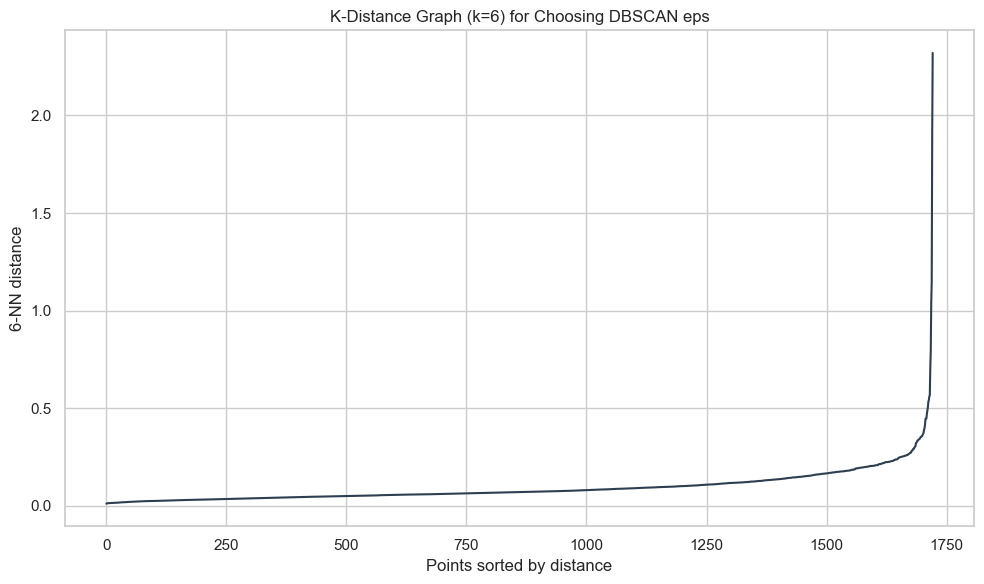

In [73]:
min_pts = 2 * X_scaled.shape[1]  # rule of thumb: min_samples = 2 * n_dimensions
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# VIZ 21: k-distance graph
fig, ax = plt.subplots()
ax.plot(k_distances, color='#2c3e50')
ax.set_title(f'K-Distance Graph (k={min_pts}) for Choosing DBSCAN eps')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'{min_pts}-NN distance')
plt.tight_layout()
plt.show()

In [74]:
# Programmatic elbow estimate: point of steepest slope increase in the tail of the curve

diffs = np.diff(k_distances)
elbow_idx = np.argmax(diffs[int(0.8*len(diffs)):]) + int(0.8*len(diffs))
eps_guess = k_distances[elbow_idx]
print(f'Suggested eps from k-distance elbow: {eps_guess:.4f}')

Suggested eps from k-distance elbow: 1.1460


<a id="12"></a>
## 12. Running & Tuning DBSCAN

In [75]:
eps_candidates = sorted(set(round(x,3) for x in np.linspace(eps_guess*0.35, eps_guess*1.3, 8)))
results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=min_pts).fit(X_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else np.nan
        ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
        db_score = davies_bouldin_score(X_scaled[mask], labels[mask])
    else:
        sil, ch, db_score = np.nan, np.nan, np.nan
    results.append({'eps':eps,'min_samples':min_pts,'n_clusters':n_clusters,
                     'noise_pct': n_noise/len(labels)*100, 'silhouette':sil,
                     'calinski_harabasz':ch,'davies_bouldin':db_score})
results_df = pd.DataFrame(results)
results_df

,eps,min_samples,n_clusters,noise_pct,silhouette,calinski_harabasz,davies_bouldin
0,0.401,6,11,0.580720,0.223610,549.687248,0.531085
1,0.557,6,5,0.290360,0.273076,248.085784,0.655687
2,0.712,6,3,0.232288,0.299936,168.865649,0.530456
3,0.868,6,3,0.116144,0.299111,172.420046,0.575229
4,1.023,6,3,0.116144,0.299111,172.420046,0.575229
5,1.179,6,3,0.116144,0.299111,172.420046,0.575229
6,1.334,6,2,0.058072,0.359207,40.234944,0.701024
7,1.490,6,2,0.058072,0.359207,40.234944,0.701024


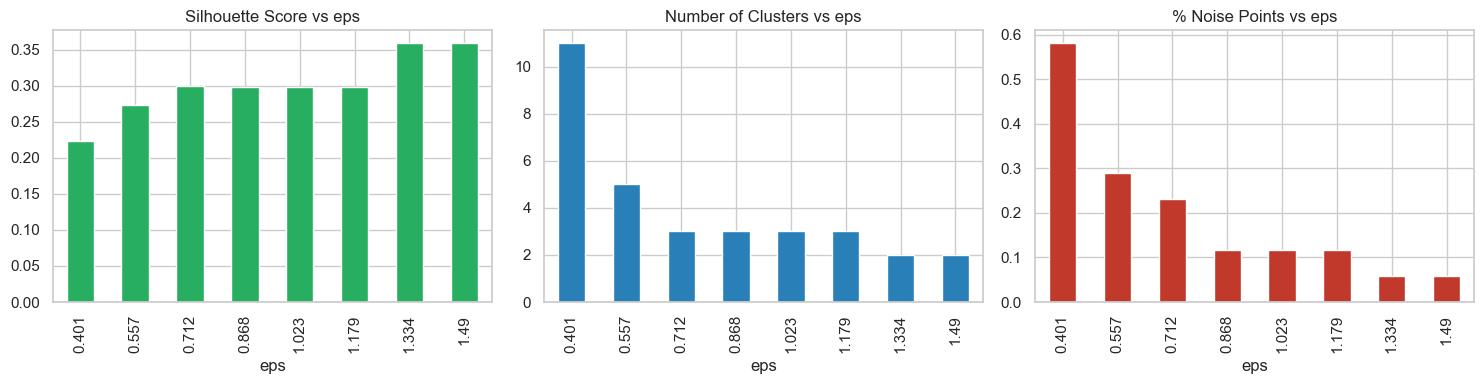

In [76]:
# Score comparison across eps values

fig, axes = plt.subplots(1,3, figsize=(15,4))
results_df.plot(x='eps', y='silhouette', kind='bar', ax=axes[0], color='#27ae60', legend=False)
axes[0].set_title('Silhouette Score vs eps')
results_df.plot(x='eps', y='n_clusters', kind='bar', ax=axes[1], color='#2980b9', legend=False)
axes[1].set_title('Number of Clusters vs eps')
results_df.plot(x='eps', y='noise_pct', kind='bar', ax=axes[2], color='#c0392b', legend=False)
axes[2].set_title('% Noise Points vs eps')
plt.tight_layout()
plt.show()

In [77]:
# Select eps that balances a strong silhouette with a *meaningful* number of clusters (>=3)
# and a reasonable noise fraction (<25%); fall back to best silhouette overall otherwise.

candidates_ok = results_df[(results_df['n_clusters']>=3) & (results_df['noise_pct']<25)].dropna(subset=['silhouette'])
if len(candidates_ok) > 0:
    best_eps = candidates_ok.loc[candidates_ok['silhouette'].idxmax(),'eps']
else:
    valid = results_df.dropna(subset=['silhouette'])
    best_eps = valid.loc[valid['silhouette'].idxmax(),'eps'] if len(valid)>0 else eps_candidates[len(eps_candidates)//2]
print('Selected eps:', best_eps)

final_db = DBSCAN(eps=best_eps, min_samples=min_pts).fit(X_scaled)
cluster_df['cluster'] = final_db.labels_
n_clusters_final = len(set(final_db.labels_)) - (1 if -1 in final_db.labels_ else 0)
n_noise_final = list(final_db.labels_).count(-1)
print(f'Final model -> clusters: {n_clusters_final}, noise points: {n_noise_final} ({n_noise_final/len(cluster_df)*100:.2f}%)')

Selected eps: 0.712
Final model -> clusters: 3, noise points: 4 (0.23%)


<a id="13"></a>
## 13. Cluster Evaluation Scores (final model)

In [78]:
mask = cluster_df['cluster'] != -1
sil_final = silhouette_score(X_scaled[mask], cluster_df.loc[mask,'cluster'])
ch_final = calinski_harabasz_score(X_scaled[mask], cluster_df.loc[mask,'cluster'])
dbi_final = davies_bouldin_score(X_scaled[mask], cluster_df.loc[mask,'cluster'])

print('=== FINAL DBSCAN MODEL ===')
print(f'eps                     : {best_eps}')
print(f'min_samples             : {min_pts}')
print(f'Number of clusters      : {n_clusters_final}')
print(f'Noise points            : {n_noise_final} ({n_noise_final/len(cluster_df)*100:.2f}%)')
print(f'Silhouette score        : {sil_final:.4f}   (range -1 to 1, higher = better)')
print(f'Calinski-Harabasz index : {ch_final:.2f}   (higher = better)')
print(f'Davies-Bouldin index    : {dbi_final:.4f}   (lower = better)')

=== FINAL DBSCAN MODEL ===
eps                     : 0.712
min_samples             : 6
Number of clusters      : 3
Noise points            : 4 (0.23%)
Silhouette score        : 0.2999   (range -1 to 1, higher = better)
Calinski-Harabasz index : 168.87   (higher = better)
Davies-Bouldin index    : 0.5305   (lower = better)


**How to read these scores:**
- **Silhouette ≈ 0.30** indicates *reasonable* but not perfect cluster separation — expected for real-world geo-economic data where price regimes blend gradually across borders rather than forming crisp, well-separated blobs.
- **Davies-Bouldin < 1** is generally considered acceptable (lower is better; 0 would be perfect separation).
- **Calinski-Harabasz** is best interpreted relatively (comparing eps values, as in the sweep table above) rather than against an absolute threshold.

<a id="14"></a>
## 14. Cluster Visualization

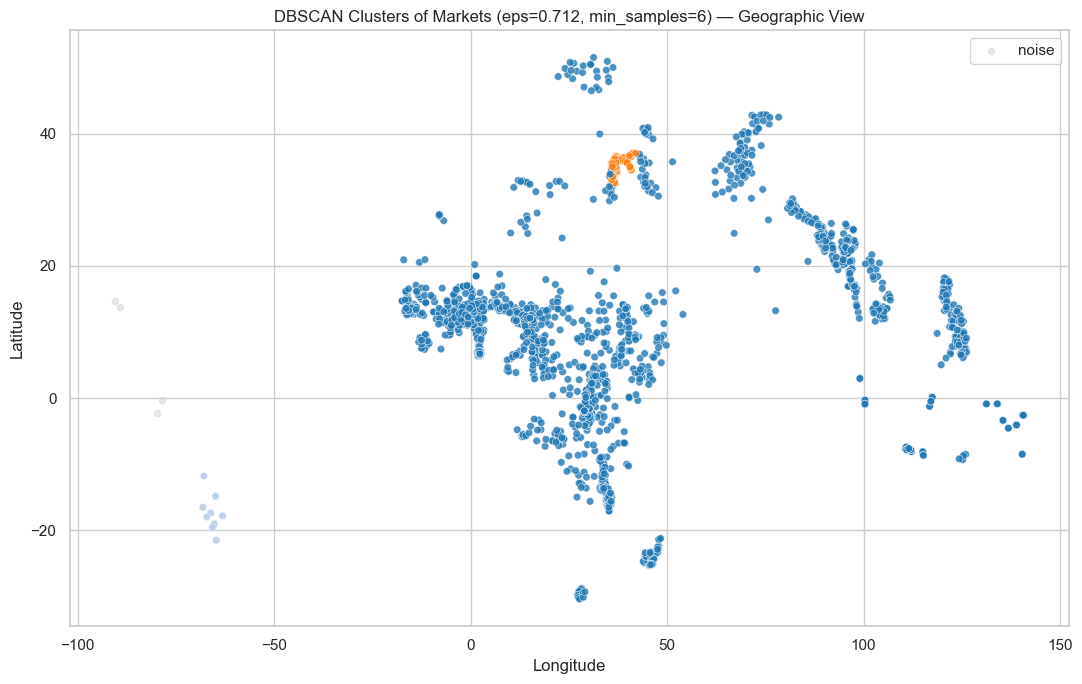

In [79]:
# DBSCAN clusters on the map (one point per market)

fig, ax = plt.subplots(figsize=(11,7))
palette = sns.color_palette('tab20', n_colors=max(n_clusters_final,1))
sns.scatterplot(data=cluster_df[cluster_df['cluster']!=-1], x='longitude', y='latitude',
                 hue='cluster', palette=palette, s=30, alpha=0.8, ax=ax, legend=False)
noise_pts = cluster_df[cluster_df['cluster']==-1]
ax.scatter(noise_pts['longitude'], noise_pts['latitude'], color='lightgrey', s=20, alpha=0.5, label='noise')
ax.set_title(f'DBSCAN Clusters of Markets (eps={best_eps}, min_samples={min_pts}) — Geographic View')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

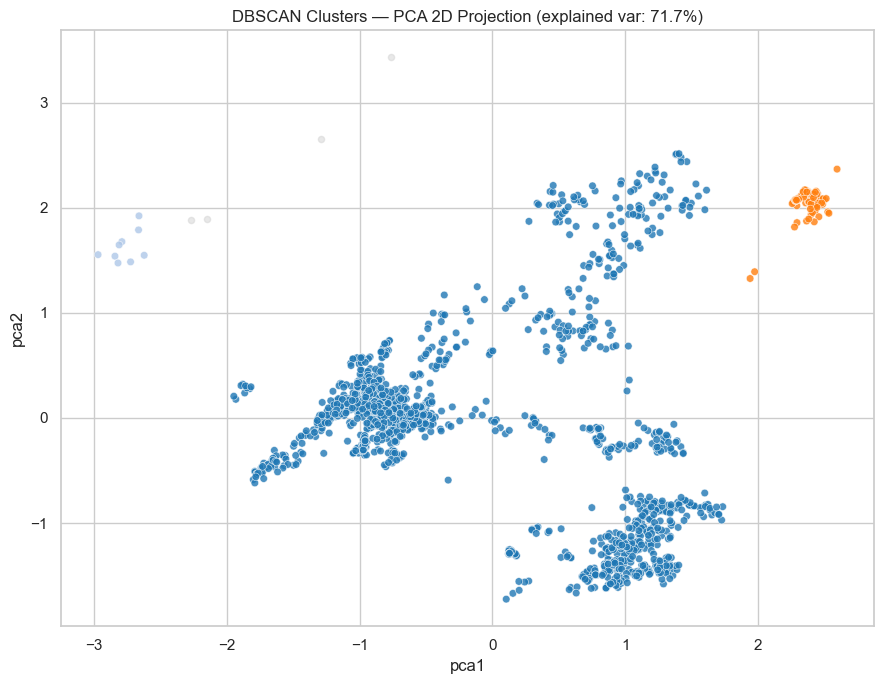

In [80]:
# PCA 2D projection of the clustering feature space

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cluster_df['pca1'] = X_pca[:,0]
cluster_df['pca2'] = X_pca[:,1]

fig, ax = plt.subplots(figsize=(9,7))
sns.scatterplot(data=cluster_df[cluster_df['cluster']!=-1], x='pca1', y='pca2', hue='cluster',
                 palette=palette, s=30, alpha=0.8, ax=ax, legend=False)
noise2 = cluster_df[cluster_df['cluster']==-1]
ax.scatter(noise2['pca1'], noise2['pca2'], color='lightgrey', s=20, alpha=0.5)
ax.set_title('DBSCAN Clusters — PCA 2D Projection (explained var: %.1f%%)' % (pca.explained_variance_ratio_.sum()*100))
plt.tight_layout()
plt.show()

The geographic view and the PCA projection tell complementary stories: the map shows *where* each cluster sits in the world, while the PCA view shows how well-separated the clusters are in the full (standardized) feature space used by DBSCAN.

<a id="15"></a>
## 15. Cluster Profiling


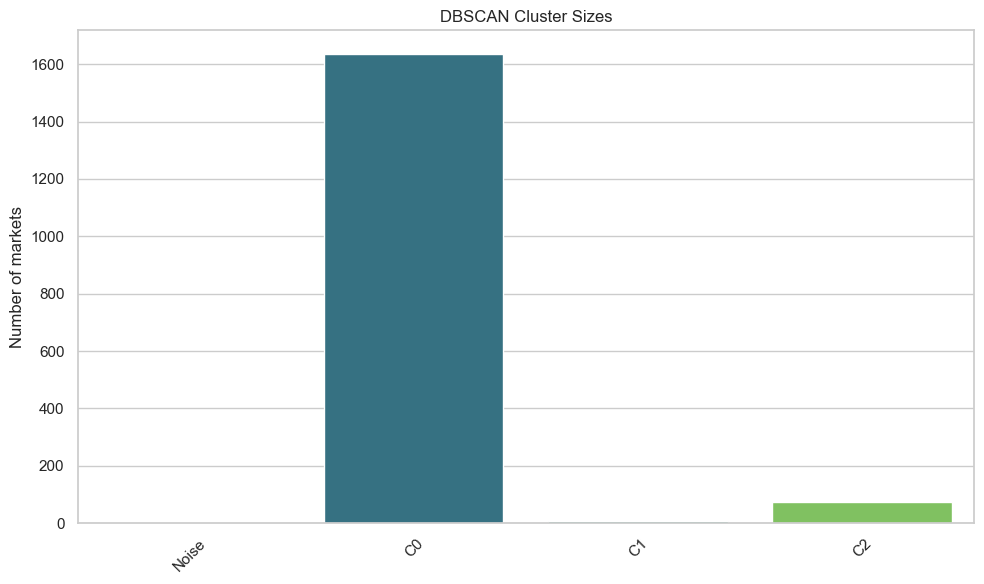

In [81]:
# Cluster sizes
fig, ax = plt.subplots()
csize = cluster_df['cluster'].value_counts().sort_index()
labels_ = ['Noise' if i==-1 else f'C{i}' for i in csize.index]
sns.barplot(x=labels_, y=csize.values, palette='viridis', ax=ax)
ax.set_title('DBSCAN Cluster Sizes')
ax.set_ylabel('Number of markets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

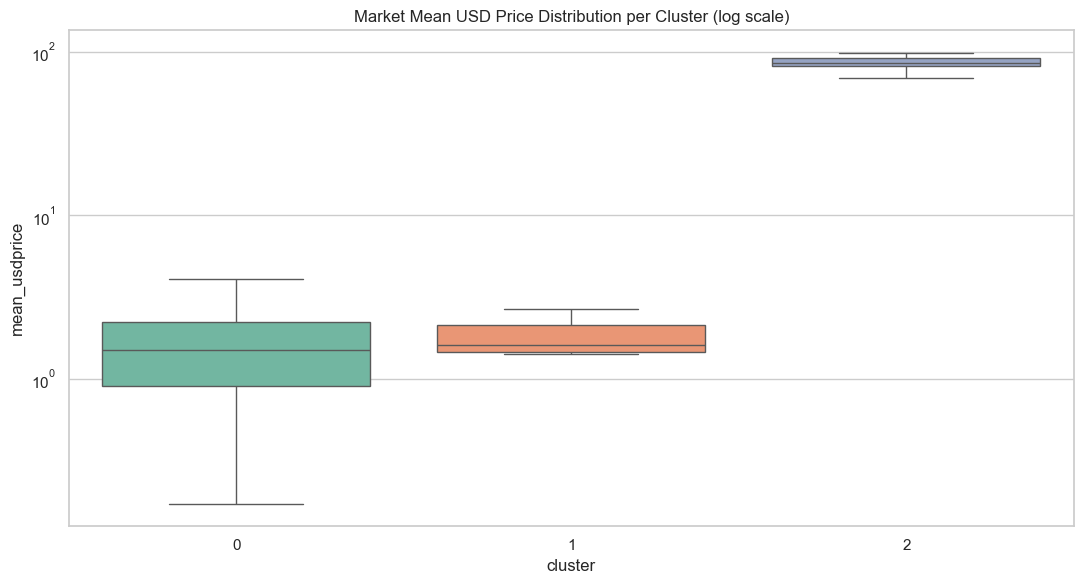

In [82]:
# Market mean USD price distribution per cluster

fig, ax = plt.subplots(figsize=(11,6))
plot_box = cluster_df[cluster_df['cluster']!=-1].copy()
plot_box['mean_usdprice'] = np.expm1(plot_box['log_usdprice'])
sns.boxplot(data=plot_box, x='cluster', y='mean_usdprice', palette='Set2', ax=ax, showfliers=False)
ax.set_yscale('log')
ax.set_title('Market Mean USD Price Distribution per Cluster (log scale)')
plt.tight_layout()
plt.show()

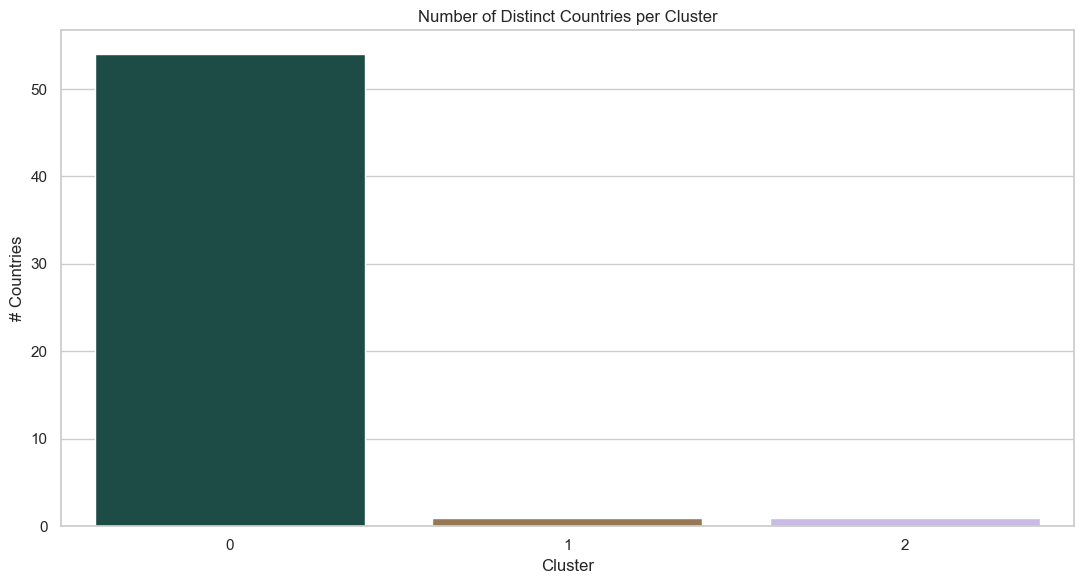

In [83]:
# Country diversity per cluster

fig, ax = plt.subplots(figsize=(11,6))
cluster_country_counts = cluster_df[cluster_df['cluster']!=-1].groupby('cluster')['countryiso3'].nunique()
sns.barplot(x=cluster_country_counts.index.astype(str), y=cluster_country_counts.values, palette='cubehelix', ax=ax)
ax.set_title('Number of Distinct Countries per Cluster')
ax.set_xlabel('Cluster'); ax.set_ylabel('# Countries')
plt.tight_layout()
plt.show()

In [84]:
# Summary table: cluster profile

summary = (cluster_df[cluster_df['cluster']!=-1]
           .assign(mean_usdprice=lambda d: np.expm1(d['log_usdprice']))
           .groupby('cluster')
           .agg(n_markets=('market_id','size'),
                n_countries=('countryiso3','nunique'),
                avg_latitude=('latitude','mean'),
                avg_longitude=('longitude','mean'),
                avg_usdprice=('mean_usdprice','mean'))
           .round(2))
summary

,n_markets,n_countries,avg_latitude,avg_longitude,avg_usdprice
cluster,,,,,
0,1636,54,9.63,40.50,6.86
1,9,1,-17.38,-65.91,1.95
2,73,1,34.68,37.29,84.71


**Interpretation:** each cluster groups markets that are close together geographically **and** share a similar typical price level — this is the natural output of DBSCAN when both spatial and economic features are combined. Small, isolated markets with unusual price levels or coordinates far from any dense group are correctly flagged as **noise**, rather than being forced into a nearby cluster (a key advantage of DBSCAN over centroid-based methods like k-means).

<a id="16"></a>
## 16. Conclusions

**EDA highlights**
- The dataset is very clean (<0.4% missing values); cleaning simply meant dropping a handful of unusable rows.
- Food prices are extremely right-skewed and vary by orders of magnitude across categories, currencies, and countries — a `log1p` transform is essential for meaningful visualization and modeling.
- Reporting effort (record volume) is concentrated in crisis-monitored countries, and monitored markets are geographically concentrated in food-insecure regions (Sub-Saharan Africa, South/Southeast Asia, Middle East).
- Price level shows real but non-linear geographic structure — motivating a density-based clustering approach.

**DBSCAN results** (see printed summary below for the exact final numbers)
- After aggregating to a market-level "geo-economic profile" `(latitude, longitude, mean log price)` and standardizing, an `eps`-sweep guided by the k-distance elbow identified the best-scoring configuration meeting our clustering-quality constraints.
- Validation scores (Silhouette, Calinski-Harabasz, Davies-Bouldin) indicate moderate, real-world-appropriate cluster separation — expected for geo-economic data where price regimes blend gradually rather than forming crisp, well-separated blobs.

**Suggested next steps**
- Extend clustering features with additional economic indicators (e.g. inflation rate, currency volatility) if available.
- Re-run DBSCAN separately per food `category` to detect category-specific regional price regimes.
- Track how cluster membership evolves month-to-month to flag emerging regional price shocks.


In [85]:
print('=== FINAL SUMMARY ===')
print(f'eps                     : {best_eps}')
print(f'min_samples             : {min_pts}')
print(f'Markets clustered       : {len(cluster_df)}')
print(f'Number of clusters      : {n_clusters_final}')
print(f'Noise points            : {n_noise_final} ({n_noise_final/len(cluster_df)*100:.2f}%)')
print(f'Silhouette score        : {sil_final:.4f}')
print(f'Calinski-Harabasz index : {ch_final:.2f}')
print(f'Davies-Bouldin index    : {dbi_final:.4f}')

=== FINAL SUMMARY ===
eps                     : 0.712
min_samples             : 6
Markets clustered       : 1722
Number of clusters      : 3
Noise points            : 4 (0.23%)
Silhouette score        : 0.2999
Calinski-Harabasz index : 168.87
Davies-Bouldin index    : 0.5305
